In [ ]:
%run 10_MNESIS_polychronous-chains.ipynb

## working memory with the Lorentz attractor

Setting up:

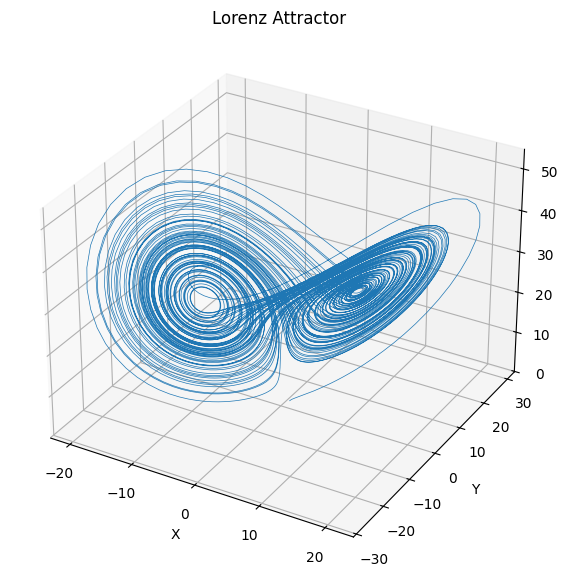

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Lorenz system parameters
sigma = 10.0
rho = 28.0
beta = 8.0/3.0

# Time parameters
dt = 0.01
steps = 10000

# Initial conditions
x = 1.0
y = 1.0
z = 1.0

# Store trajectory
trajectory = np.zeros((steps, 3))
trajectory[0] = [x, y, z]

# Integration loop (Euler method)
for i in range(1, steps):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    
    x += dx * dt
    y += dy * dt
    z += dz * dt
    
    trajectory[i] = [x, y, z]

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], lw=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Lorenz Attractor")
plt.show()

## Transform the attractor into spikes

Trajectory shape: (1000, 3)
Binary codes shape: (1000, 1024)
Sparsity: 0.500


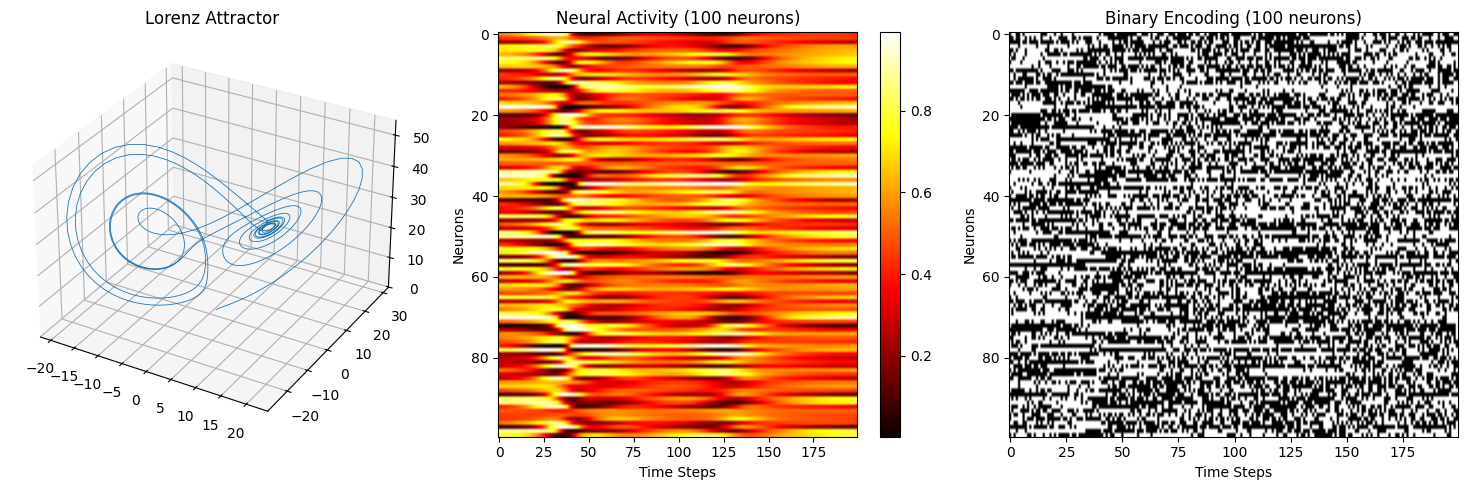

Reconstruction MSE: 70.7622


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate Lorenz attractor trajectory
def generate_lorenz(steps=1000, dt=0.01):
    sigma, rho, beta = 10.0, 28.0, 8.0/3.0
    x, y, z = 1.0, 1.0, 1.0
    
    trajectory = np.zeros((steps, 3))
    trajectory[0] = [x, y, z]
    
    for i in range(1, steps):
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        
        x += dx * dt
        y += dy * dt
        z += dz * dt
        trajectory[i] = [x, y, z]
    
    return trajectory

# Project to high-dimensional space and encode
def encode_trajectory(trajectory, n_neurons=1024):
    # Normalize trajectory
    traj_norm = (trajectory - trajectory.mean(axis=0)) / trajectory.std(axis=0)
    
    # Random projection matrix (fixed for reproducibility)
    np.random.seed(42)
    W = np.random.randn(traj_norm.shape[1], n_neurons) * 0.5
    
    # Project to neural space
    neural_activity = traj_norm @ W
    
    # Apply sigmoid activation
    sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to prevent overflow
    neural_activity = sigmoid(neural_activity)
    
    # Generate binary codes via Bernoulli trials
    binary_codes = (np.random.random(neural_activity.shape) < neural_activity).astype(np.uint8)
    
    return binary_codes, neural_activity

# Generate and encode
trajectory = generate_lorenz(1000)
binary_codes, neural_activity = encode_trajectory(trajectory, 1024)

print(f"Trajectory shape: {trajectory.shape}")
print(f"Binary codes shape: {binary_codes.shape}")
print(f"Sparsity: {binary_codes.mean():.3f}")

# Visualization
fig = plt.figure(figsize=(15, 5))

# Original attractor
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], lw=0.6)
ax1.set_title('Lorenz Attractor')

# Neural activity example (first 100 neurons, first 200 timesteps)
ax2 = fig.add_subplot(132)
im = ax2.imshow(neural_activity[:200, :100].T, aspect='auto', cmap='hot')
ax2.set_title('Neural Activity (100 neurons)')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Neurons')
plt.colorbar(im, ax=ax2)

# Binary encoding example
ax3 = fig.add_subplot(133)
ax3.imshow(binary_codes[:200, :100].T, aspect='auto', cmap='gray')
ax3.set_title('Binary Encoding (100 neurons)')
ax3.set_xlabel('Time Steps')
ax3.set_ylabel('Neurons')

plt.tight_layout()
plt.show()

# Example decoding/reconstruction
def decode_position(binary_codes, trajectory, n_samples=100):
    """Simple decoding: find closest matching binary pattern"""
    # Take sample patterns
    indices = np.random.choice(len(trajectory), n_samples, replace=False)
    reference_codes = binary_codes[indices]
    
    # For each point, find best match
    reconstructed = []
    for i in range(len(binary_codes)):
        # Hamming distance to all references
        distances = np.sum(binary_codes[i] != reference_codes, axis=1)
        best_match = indices[np.argmin(distances)]
        reconstructed.append(trajectory[best_match])
    
    return np.array(reconstructed)

# Demonstrate reconstruction quality
reconstructed = decode_position(binary_codes, trajectory, 100)
mse = np.mean((trajectory - reconstructed)**2)
print(f"Reconstruction MSE: {mse:.4f}")

In [ ]:
opt = Params()
hd = HD_SNN(opt)
hd.net.to(hd.opt.device)
hd.target.shape, opt

In [ ]:

hd.target[:, :, (-hd.opt.num_delay):] = hd.target[:, :, :hd.opt.num_delay]

## Learn the periodic target

In [ ]:
model_filename = data_cache / f"{hd.opt.datetag}_periodic.pth"
lock_filename = data_cache / model_filename.with_suffix('.lock')
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        hd.learn_model()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

In [ ]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=hd.opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = hd.target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_pattern, :, :].sum().item(), hd.target[i_pattern, :, :].sum().item()

## Retrieve a periodic memory

In [ ]:
N_repeat = 30

In [ ]:
hd.target.shape

In [ ]:
with torch.no_grad():    
    target_full = torch.nn.functional.pad(hd.target[:, :, :(-hd.opt.num_delay)].repeat(1, 1, N_repeat), (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=N_repeat*(opt.N_time-opt.num_delay))
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target_full[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    
    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

In [ ]:
target_full.shape, input_spikes.shape, spikes.shape

In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_pattern, :, :].sum().item(), hd.target[i_pattern, :, :].sum().item()

## Retrieve a periodic memory with a little bit of noise

In [ ]:
with torch.no_grad():

    target_full = torch.nn.functional.pad(hd.target[:, :, :(-hd.opt.num_delay)].repeat(1, 1, N_repeat), (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=N_repeat*(opt.N_time-opt.num_delay))
    input_spikes = flip_bits(input_spikes, .323)

    _, _, spikes = hd.forward_pass(input_spikes)

    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target_full[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

In [ ]:
target_full.shape, spikes.shape, input_spikes.shape

In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_pattern, :, :].sum().item(), hd.target[i_pattern, :, :].sum().item()

In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.plot(spikes.mean(dim=[0, 1]).cpu(), alpha=.2)
# ax.plot(spikes[i_pattern, ...].mean(dim=0).cpu(), alpha=.7)
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Firing rate (Hz)")
spikes.shape, target_full.shape

## Retrieve a periodic memory with different levels of noise

In [ ]:
def get_scores_noise(N_scan=opt.N_scan, N_chunk=100):
    p_noise = np.linspace(0, 1, N_scan, endpoint=True)
    time_chunk = (N_repeat*(opt.N_time-opt.num_delay) + 2 * opt.N_pretime) // N_chunk
    scores_np = np.zeros((N_scan, N_chunk))
    for i_scan in trange(N_scan):
        with torch.no_grad():

            target_full = torch.nn.functional.pad(hd.target[:, :, :(-hd.opt.num_delay)].repeat(1, 1, N_repeat), (opt.N_pretime, opt.N_pretime))
            input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=N_repeat*(opt.N_time-opt.num_delay))
            input_spikes = flip_bits(input_spikes, p_noise[i_scan])

            _, _, spikes = hd.forward_pass(input_spikes)

            spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
            target_evoked = target_full[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]


            input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=hd.opt.N_time)
            _, _, spikes = hd.forward_pass(input_spikes)
            spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
            target_evoked = hd.target[:, :, hd.opt.num_delay:]
            for i_chunk in trange(N_chunk):
                scores_np[i_scan, i_chunk] = get_f1score(spikes[:, :, (i_chunk*time_chunk):((i_chunk+1)*time_chunk)],
                                                        hd.target[:, :, (i_chunk*time_chunk):((i_chunk+1)*time_chunk)])

    return p_noise, scores_np

npy_filename = data_cache / f"{hd.opt.datetag}_periodic-noise.npz"
lock_filename = data_cache / npy_filename.with_suffix('.lock')
RECOMPUTE = True
if RECOMPUTE:
    npy_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    data = np.load(npy_filename)
    p_noise = data['p_noise']
    scores_np = data['scores_np']
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Score weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Score file not found: {model_filename}, evaluating athe score.")
        lock_filename.touch(exist_ok=True)
        ##################
        p_noise, scores_np = get_scores_noise()
        ##################        
        np.savez(npy_filename, p_noise=p_noise, scores_np=scores_np)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Score file is locked: {lock_filename}, passing.")


In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
for i_scan in range(N_scan):
    ax.plot(scores_np[i_scan, :], label=f'p_noise={p_noise[i_scan]:.2f}')
ax.set_xlabel("Time chunk")
ax.set_ylabel("F1 score")
ax.legend() 